In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.3 MB/s eta 0:00:00


In [ ]:
# Import Libraries

import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import resnet50, ResNet50_Weights,mobilenetv3,MobileNet_V3_Large_Weights
from sklearn.metrics import classification_report, confusion_matrix

# **Understand the Dataset**

In [ ]:
# Inspect Dataset Folder Structure

def check_structure(data_path):
    for root, dirs, files in os.walk(data_path):
        level = root.replace(data_path, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f"{indent}{os.path.basename(root)}/")
        subindent = ' ' * 4 * (level + 1)
        # Show first 3 files as examples
        for f in files[:3]:
            print(f"{subindent}{f}")

check_structure('/content/drive/MyDrive/datascience/Mini Projects/Aerial Object Classification & Detection/classification_dataset/train')

train/
    drone/
        moto02524_png.rf.10e6d2488f18658a239608c44d7695f8.jpg
        pic_078_jpg.rf.40ff28aab6e28b73f95ed1aa3a928b34.jpg
        foto05134_png.rf.e30a81827d620d63a723bedcc2982b07.jpg
    bird/
        04cf5e8139d4037e_jpg.rf.5e92ea372a305d74700f1f683951c5e3.jpg
        0f99c67cdb98d823_jpg.rf.30dc3e60176e29f3ac1544cf8d43faab.jpg
        10d1c5fc3b587f37_jpg.rf.bd9f165b81103c4ca5af9a5d0cb3b050.jpg


In [ ]:
# Check Number of Images & Identify Class Imbalance

def get_class_stats(data_path):
    stats = []
    for label in os.listdir(data_path):
        label_path = os.path.join(data_path, label)
        if os.path.isdir(label_path):
            count = len(os.listdir(label_path))
            stats.append({'class': label, 'count': count})

    df = pd.DataFrame(stats)
    print(df.sort_values(by='count', ascending=False))
    return df

stats_df = get_class_stats('/content/drive/MyDrive/datascience/Mini Projects/Aerial Object Classification & Detection/classification_dataset/train')


   class  count
1   bird   1414
0  drone   1248


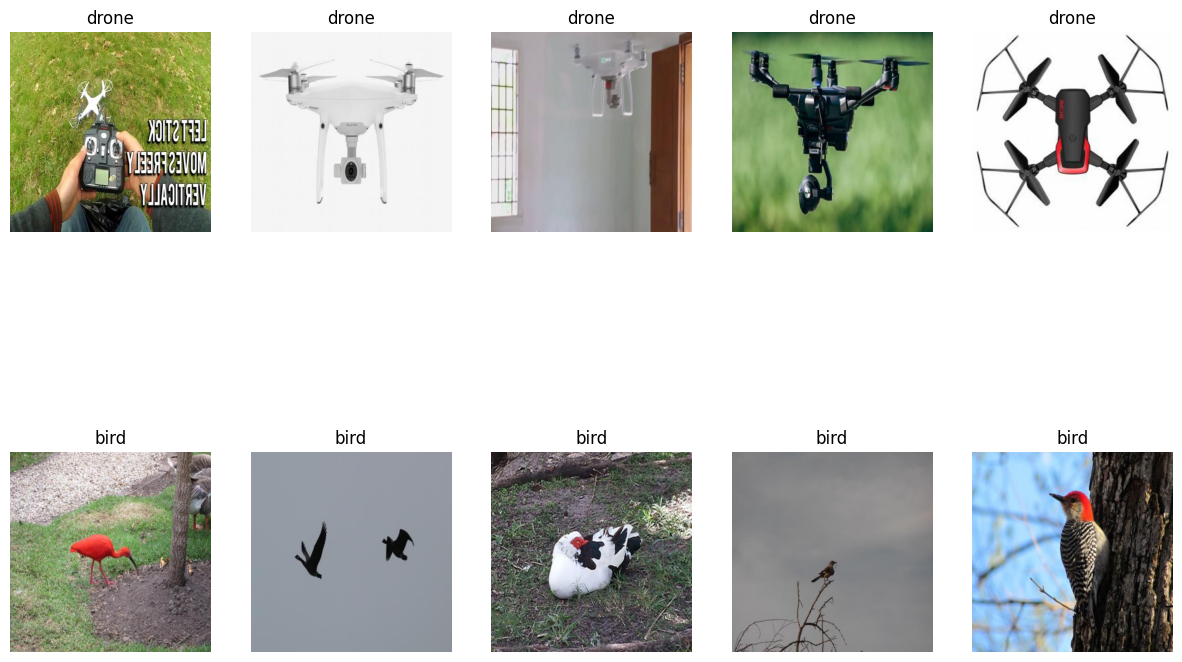

In [ ]:
# Visualize Sample Images

def plot_samples(data_path, n=5):
    classes = os.listdir(data_path)
    fig, axes = plt.subplots(len(classes), n, figsize=(15, 10))

    for i, cls in enumerate(classes):
        cls_path = os.path.join(data_path, cls)
        images = os.listdir(cls_path)[:n]
        for j, img_name in enumerate(images):
            img = Image.open(os.path.join(cls_path, img_name))
            axes[i, j].imshow(img)
            axes[i, j].set_title(cls)
            axes[i, j].axis('off')
    plt.show()

plot_samples('/content/drive/MyDrive/datascience/Mini Projects/Aerial Object Classification & Detection/classification_dataset/train')


# **Data Preprocessing**

In [ ]:
# Preprocessing steps Fixed Transforms and Augmentation Pipeline
image_size = 224

transforms = transforms.Compose([
    # Resize to a slightly larger size or fixed size
    transforms.Resize(image_size),

    # Convert PIL Image to Tensor
    transforms.ToTensor()
])

In [ ]:
# Load Device

device = torch.device("cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
import torch
print(torch.cpu.is_available())

True


In [ ]:
# Load Dataset

train_dataset = torchvision.datasets.ImageFolder("/content/drive/MyDrive/datascience/Mini Projects/Aerial Object Classification & Detection/classification_dataset/train", transform=transforms)
valid_dataset = torchvision.datasets.ImageFolder("/content/drive/MyDrive/datascience/Mini Projects/Aerial Object Classification & Detection/classification_dataset/valid", transform=transforms)

In [ ]:
train_dataset.classes

['bird', 'drone']

In [ ]:
valid_dataset

Dataset ImageFolder
    Number of datapoints: 442
    Root location: /content/drive/MyDrive/datascience/Mini Projects/Aerial Object Classification & Detection/classification_dataset/valid
    StandardTransform
Transform: Compose(
               Resize(size=224, interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
valid_loader  = DataLoader(valid_dataset,  batch_size=16, shuffle=True, num_workers=2, pin_memory=True)

# **Model Building**

# *CNN Model*

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3), nn.ReLU(), nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*26*26,128),
            nn.ReLU(),
            nn.Linear(128,4)
        )

    def forward(self,x):
        x = self.conv(x)
        x = self.fc(x)
        return x

# *ResNet50*

In [ ]:
def get_resnet50():
    weights = ResNet50_Weights
    model = resnet50(weights=weights)

    # Freeze early layers to keep ImageNet knowledge
    for param in model.parameters():
        param.requires_grad = False

    # Replace the final fully connected layer
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 2) # bird vs drone
    return model

# *MobileNet*

In [ ]:
def get_mobilenet():
    weights = MobileNet_V3_Large_Weights.DEFAULT
    model = models.mobilenet_v3_large(weights=weights)

    # Freeze early layers to keep ImageNet knowledge
    for param in model.parameters():
        param.requires_grad = False

    # Replace the final fully connected layer
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, 2)

    return model

# **Model Training**

In [ ]:
def train_model(model, train_loader, valid_loader, epochs, model_name):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

    best_acc = 0.0

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total
        train_loss = running_loss / len(train_loader)

        # 🔹 Validation
        model.eval()
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in valid_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                _, predicted = torch.max(outputs, 1)

                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total

        print(f"{model_name} | Epoch [{epoch+1}/{epochs}] "
              f"Loss: {train_loss:.4f} "
              f"Train Acc: {train_acc:.4f} "
              f"Val Acc: {val_acc:.4f}")

        # ✅ Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f"{model_name}_best.pth")

    print(f"Best Val Accuracy for {model_name}: {best_acc:.4f}")

In [ ]:
cnn_model = CustomCNN()
train_model(cnn_model, train_loader, valid_loader, epochs=10, model_name="custom_cnn")

custom_cnn | Epoch [1/10] Loss: 0.6180 Train Acc: 0.6615 Val Acc: 0.7262
custom_cnn | Epoch [2/10] Loss: 0.4826 Train Acc: 0.7573 Val Acc: 0.7624
custom_cnn | Epoch [3/10] Loss: 0.4281 Train Acc: 0.7979 Val Acc: 0.7262
custom_cnn | Epoch [4/10] Loss: 0.3743 Train Acc: 0.8351 Val Acc: 0.7941
custom_cnn | Epoch [5/10] Loss: 0.3330 Train Acc: 0.8557 Val Acc: 0.7738
custom_cnn | Epoch [6/10] Loss: 0.3133 Train Acc: 0.8787 Val Acc: 0.8077
custom_cnn | Epoch [7/10] Loss: 0.2913 Train Acc: 0.8772 Val Acc: 0.8303
custom_cnn | Epoch [8/10] Loss: 0.2517 Train Acc: 0.8989 Val Acc: 0.8326
custom_cnn | Epoch [9/10] Loss: 0.2158 Train Acc: 0.9215 Val Acc: 0.8416
custom_cnn | Epoch [10/10] Loss: 0.2038 Train Acc: 0.9219 Val Acc: 0.8281
Best Val Accuracy for custom_cnn: 0.8416


In [ ]:
resnet_model = get_resnet50()
train_model(resnet_model, train_loader, valid_loader, epochs=10, model_name="ResNet50")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 162MB/s]


ResNet50 | Epoch [1/10] Loss: 0.4024 Train Acc: 0.8775 Val Acc: 0.9321
ResNet50 | Epoch [2/10] Loss: 0.2282 Train Acc: 0.9380 Val Acc: 0.9434
ResNet50 | Epoch [3/10] Loss: 0.1876 Train Acc: 0.9437 Val Acc: 0.9480
ResNet50 | Epoch [4/10] Loss: 0.1528 Train Acc: 0.9549 Val Acc: 0.9525
ResNet50 | Epoch [5/10] Loss: 0.1513 Train Acc: 0.9530 Val Acc: 0.9548
ResNet50 | Epoch [6/10] Loss: 0.1283 Train Acc: 0.9594 Val Acc: 0.9593
ResNet50 | Epoch [7/10] Loss: 0.1172 Train Acc: 0.9636 Val Acc: 0.9615
ResNet50 | Epoch [8/10] Loss: 0.1201 Train Acc: 0.9598 Val Acc: 0.9615
ResNet50 | Epoch [9/10] Loss: 0.1103 Train Acc: 0.9681 Val Acc: 0.9615
ResNet50 | Epoch [10/10] Loss: 0.1067 Train Acc: 0.9651 Val Acc: 0.9638
Best Val Accuracy for ResNet50: 0.9638


In [ ]:
mobilenet_model = get_mobilenet()
train_model(mobilenet_model, train_loader, valid_loader, epochs=10, model_name="MobileNet")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 141MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


MobileNet | Epoch [1/10] Loss: 0.5557 Train Acc: 0.8013 Val Acc: 0.9231
MobileNet | Epoch [2/10] Loss: 0.3851 Train Acc: 0.9177 Val Acc: 0.9525
MobileNet | Epoch [3/10] Loss: 0.2967 Train Acc: 0.9421 Val Acc: 0.9502
MobileNet | Epoch [4/10] Loss: 0.2463 Train Acc: 0.9489 Val Acc: 0.9548
MobileNet | Epoch [5/10] Loss: 0.2201 Train Acc: 0.9515 Val Acc: 0.9548
MobileNet | Epoch [6/10] Loss: 0.1942 Train Acc: 0.9527 Val Acc: 0.9525
MobileNet | Epoch [7/10] Loss: 0.1788 Train Acc: 0.9621 Val Acc: 0.9570
MobileNet | Epoch [8/10] Loss: 0.1682 Train Acc: 0.9515 Val Acc: 0.9570
MobileNet | Epoch [9/10] Loss: 0.1604 Train Acc: 0.9519 Val Acc: 0.9525
MobileNet | Epoch [10/10] Loss: 0.1442 Train Acc: 0.9639 Val Acc: 0.9570
Best Val Accuracy for MobileNet: 0.9570


# **Model Evaluation**

In [ ]:
test_data = torchvision.datasets.ImageFolder("/content/drive/MyDrive/datascience/Mini Projects/Aerial Object Classification & Detection/classification_dataset/test", transform=transforms)
test_loader = DataLoader(test_data, batch_size=16)

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    # Initialize lists to collect all predictions and true labels
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            # Extend lists with predictions and labels from the current batch
            all_preds.extend(predicted.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

    # Print evaluation metrics before returning accuracy
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

    print("Confusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))

    return correct / total

In [ ]:
# Initialize and load model weights cleanly
model = get_resnet50()
model.load_state_dict(torch.load("/content/drive/MyDrive/datascience/Mini Projects/Aerial Object Classification & Detection/ResNet50_best.pth"))
model = model.to(device)

test_acc = evaluate(model, test_loader)
print("Test Accuracy:", test_acc)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Classification Report:
              precision    recall  f1-score   support

        bird       0.97      0.97      0.97       121
       drone       0.96      0.97      0.96        94

    accuracy                           0.97       215
   macro avg       0.97      0.97      0.97       215
weighted avg       0.97      0.97      0.97       215

Confusion Matrix:
[[117   4]
 [  3  91]]
Test Accuracy: 0.9674418604651163


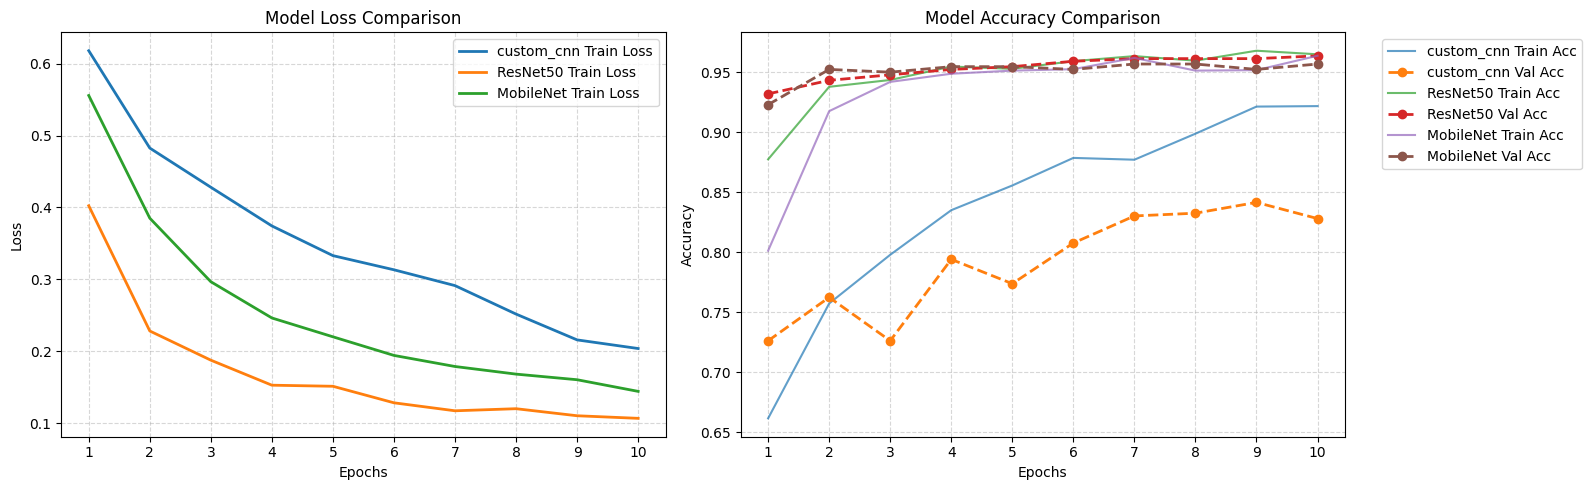

In [ ]:
import re
import matplotlib.pyplot as plt

# Paste complete logs here
log_data = """
custom_cnn | Epoch [1/10] Loss: 0.6180 Train Acc: 0.6615 Val Acc: 0.7262
custom_cnn | Epoch [2/10] Loss: 0.4826 Train Acc: 0.7573 Val Acc: 0.7624
custom_cnn | Epoch [3/10] Loss: 0.4281 Train Acc: 0.7979 Val Acc: 0.7262
custom_cnn | Epoch [4/10] Loss: 0.3743 Train Acc: 0.8351 Val Acc: 0.7941
custom_cnn | Epoch [5/10] Loss: 0.3330 Train Acc: 0.8557 Val Acc: 0.7738
custom_cnn | Epoch [6/10] Loss: 0.3133 Train Acc: 0.8787 Val Acc: 0.8077
custom_cnn | Epoch [7/10] Loss: 0.2913 Train Acc: 0.8772 Val Acc: 0.8303
custom_cnn | Epoch [8/10] Loss: 0.2517 Train Acc: 0.8989 Val Acc: 0.8326
custom_cnn | Epoch [9/10] Loss: 0.2158 Train Acc: 0.9215 Val Acc: 0.8416
custom_cnn | Epoch [10/10] Loss: 0.2038 Train Acc: 0.9219 Val Acc: 0.8281
Best Val Accuracy for custom_cnn: 0.8416

ResNet50 | Epoch [1/10] Loss: 0.4024 Train Acc: 0.8775 Val Acc: 0.9321
ResNet50 | Epoch [2/10] Loss: 0.2282 Train Acc: 0.9380 Val Acc: 0.9434
ResNet50 | Epoch [3/10] Loss: 0.1876 Train Acc: 0.9437 Val Acc: 0.9480
ResNet50 | Epoch [4/10] Loss: 0.1528 Train Acc: 0.9549 Val Acc: 0.9525
ResNet50 | Epoch [5/10] Loss: 0.1513 Train Acc: 0.9530 Val Acc: 0.9548
ResNet50 | Epoch [6/10] Loss: 0.1283 Train Acc: 0.9594 Val Acc: 0.9593
ResNet50 | Epoch [7/10] Loss: 0.1172 Train Acc: 0.9636 Val Acc: 0.9615
ResNet50 | Epoch [8/10] Loss: 0.1201 Train Acc: 0.9598 Val Acc: 0.9615
ResNet50 | Epoch [9/10] Loss: 0.1103 Train Acc: 0.9681 Val Acc: 0.9615
ResNet50 | Epoch [10/10] Loss: 0.1067 Train Acc: 0.9651 Val Acc: 0.9638
Best Val Accuracy for ResNet50: 0.9638

MobileNet | Epoch [1/10] Loss: 0.5557 Train Acc: 0.8013 Val Acc: 0.9231
MobileNet | Epoch [2/10] Loss: 0.3851 Train Acc: 0.9177 Val Acc: 0.9525
MobileNet | Epoch [3/10] Loss: 0.2967 Train Acc: 0.9421 Val Acc: 0.9502
MobileNet | Epoch [4/10] Loss: 0.2463 Train Acc: 0.9489 Val Acc: 0.9548
MobileNet | Epoch [5/10] Loss: 0.2201 Train Acc: 0.9515 Val Acc: 0.9548
MobileNet | Epoch [6/10] Loss: 0.1942 Train Acc: 0.9527 Val Acc: 0.9525
MobileNet | Epoch [7/10] Loss: 0.1788 Train Acc: 0.9621 Val Acc: 0.9570
MobileNet | Epoch [8/10] Loss: 0.1682 Train Acc: 0.9515 Val Acc: 0.9570
MobileNet | Epoch [9/10] Loss: 0.1604 Train Acc: 0.9519 Val Acc: 0.9525
MobileNet | Epoch [10/10] Loss: 0.1442 Train Acc: 0.9639 Val Acc: 0.9570
Best Val Accuracy for MobileNet: 0.9570
"""

# Dictionary to store extracted metrics for each model
data = {}

# Regex allows underscores or dashes in the model name now
pattern = r"([\w-]+) \| Epoch \[(\d+)/\d+\] Loss: ([\d.]+) Train Acc: ([\d.]+) Val Acc: ([\d.]+)"
matches = re.findall(pattern, log_data)

for name, epoch, loss, train_acc, val_acc in matches:
    if name not in data:
        data[name] = {
            "epochs": [],
            "loss": [],
            "train_acc": [],
            "val_acc": [],
        }
    data[name]["epochs"].append(int(epoch))
    data[name]["loss"].append(float(loss))
    data[name]["train_acc"].append(float(train_acc))
    data[name]["val_acc"].append(float(val_acc))

# Generate the plots
plt.figure(figsize=(16, 5))

# Plot 1: Training Loss Comparison
plt.subplot(1, 2, 1)
for model_name, metrics in data.items():
    plt.plot(
        metrics["epochs"],
        metrics["loss"],
        label=f"{model_name} Train Loss",
        linewidth=2,
    )
plt.title("Model Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

# Plot 2: Accuracy Comparison (Train vs Val for all models)
plt.subplot(1, 2, 2)
for model_name, metrics in data.items():
    # Solid line for Train Accuracy
    plt.plot(
        metrics["epochs"],
        metrics["train_acc"],
        linestyle="-",
        label=f"{model_name} Train Acc",
        alpha=0.7,
    )
    # Dashed line with marker for Validation Accuracy
    plt.plot(
        metrics["epochs"],
        metrics["val_acc"],
        linestyle="--",
        marker="o",
        label=f"{model_name} Val Acc",
        linewidth=2,
    )
plt.title("Model Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.xticks(range(1, 11))
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")  # Move legend outside
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


📊 Metric Breakdown

ResNet50 (Top Performer): It achieves the lowest overall loss (~0.10) and highest validation accuracy (~96.3%). The curves are smooth and stable, meaning the pre-trained features (or residual connections) helped it converge quickly and cleanly right from epoch 1.

MobileNet (Highly Efficient): It starts with a lower accuracy than ResNet50 at epoch 1 but catches up completely by epoch 3. It mirrors ResNet50's performance closely while utilizing far fewer parameters.

custom_cnn (Room for Improvement): It shows a healthy downward trend in loss, but its accuracy lags significantly behind the deep networks (~84%).

# **Streamlit**

In [ ]:
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 85.1 MB/s eta 0:00:00
--2026-05-25 06:38:44--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.5.0/cloudflared-linux-amd64 [following]
--2026-05-25 06:38:44--  https://github.com/cloudflare/cloudflared/releases/download/2026.5.0/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/19374280-4acc-49fd-a5af-eb955320fe42?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-05-25T07%3A25%3A45Z&rscd=attachment%3B+filename%3Dcl

In [ ]:
%%writefile pyt.py

import streamlit as st
import torch
import torch.nn as nn
from torchvision import transforms, models
from torchvision.models import resnet50, ResNet50_Weights
from PIL import Image

# -------------------------------
# PAGE CONFIGURATION
# -------------------------------

st.set_page_config(
    page_title="Aerial Object Classifier",
    page_icon="🦅",
    layout="wide"
)

# -------------------------------
# CONFIG
# -------------------------------
IMG_SIZE = 224
CLASSES = ['bird', 'drone']

device = torch.device("cpu")

# -------------------------------
# LOAD MODEL
# -------------------------------
@st.cache_resource
def get_resnet50():
    # Initialize base model structure
    weights = ResNet50_Weights
    model = resnet50(weights=weights)

    # Freeze early layers
    for param in model.parameters():
        param.requires_grad = False

    # Modify final layer to match your training setup (2 classes)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 2)

    # LOAD YOUR CUSTOM WEIGHTS HERE
    # This must happen after changing model.fc so the shapes match perfectly
    model.load_state_dict(torch.load("/content/drive/MyDrive/datascience/Mini Projects/Aerial Object Classification & Detection/ResNet50_best.pth", map_location=device))

    # Move to hardware and set to eval
    model = model.to(device)
    model.eval()
    return model

model = get_resnet50()

# -------------------------------
# IMAGE TRANSFORM
# -------------------------------
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

# -------------------------------
# UI
# -------------------------------
st.title("🦅 Bird vs 🛰️ Drone Classification (ResNet50 - PyTorch)")
st.write("Upload an image to see if it's a bird or a drone.")

uploaded_file = st.file_uploader("Upload Image", type=["jpg", "png", "jpeg"])

# -------------------------------
# PREDICTION
# -------------------------------
if uploaded_file:
    # FIX: Convert to RGB (handles 4-channel PNGs) and resize
    image = Image.open(uploaded_file).convert("RGB")

    # Display the uploaded image to the user
    st.image(image, caption="Uploaded Image", use_column_width=True)

    # Preprocess the image, add a batch dimension, and push it to the accelerator (CPU)
    img = transform(image).unsqueeze(0).to(device)

    # Run prediction
    with torch.no_grad():
        outputs = model(img)
        probs = torch.softmax(outputs, dim=1)
        confidence, pred = torch.max(probs, 1)

    predicted_class = CLASSES[pred.item()]
    confidence = confidence.item() * 100

    # Output results cleanly
    st.success(f"Prediction: {predicted_class}")
    st.info(f"Confidence: {confidence:.2f}%")

Writing pyt.py


In [ ]:
!streamlit run /content/pyt.py &>/content/logs.txt &

In [ ]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://nominated-manual-proposals-informal.trycloudflare.com
